# 03｜训练第一个小型 Transformer

现在把数据、Embedding、位置编码、Encoder Block、分类头和参数更新串起来。模型只有一层 Encoder，默认在 CPU 上运行。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "transformer_lab").is_dir():
    LAB_DIR = (LAB_DIR / "04_transformer_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

torch.set_num_threads(1)

from transformer_lab import (
    ExperimentConfig, plot_confusion_matrix, plot_model_attention,
    plot_token_sequence, plot_training_history, predict_proba,
    print_result_table, run_experiment,
)


## 五步训练循环

1. 从 DataLoader 取出 `token_ids, labels`；
2. 前向计算 `logits = model(token_ids)`；
3. 用 Cross-Entropy 计算 Loss；
4. `loss.backward()` 得到梯度；
5. AdamW 更新参数。

运行前先预测：验证 Accuracy 何时明显超过 33.3%？

In [2]:
DEVICE = "cpu"
config = ExperimentConfig(
    name="第一个 Transformer",
    content_length=12,
    d_model=32,
    num_heads=4,
    num_layers=1,
    dim_feedforward=64,
    dropout=0.1,
    activation="gelu",
    use_positional_encoding=True,
    learning_rate=0.003,
    batch_size=64,
    epochs=12,
    train_size=1200,
    val_size=300,
    test_size=300,
    seed=42,
    device=DEVICE,
)
result = run_experiment(config)
print_result_table([result])


实验                          测试Acc       参数量     更新        组合预算       秒
第一个 Transformer             99.7%     8,771    228   2,433,600    0.99


## 同时查看学习过程与最终错误

Loss 回答“模型目前错得多严重”，Accuracy 回答“答对了多少”。Gradient norm 只用于诊断训练是否异常；不能直接作为模型优劣分数。

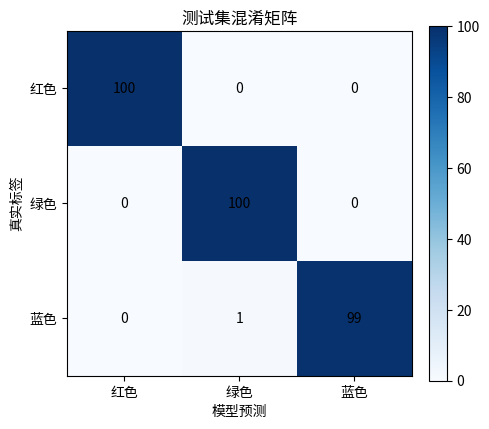

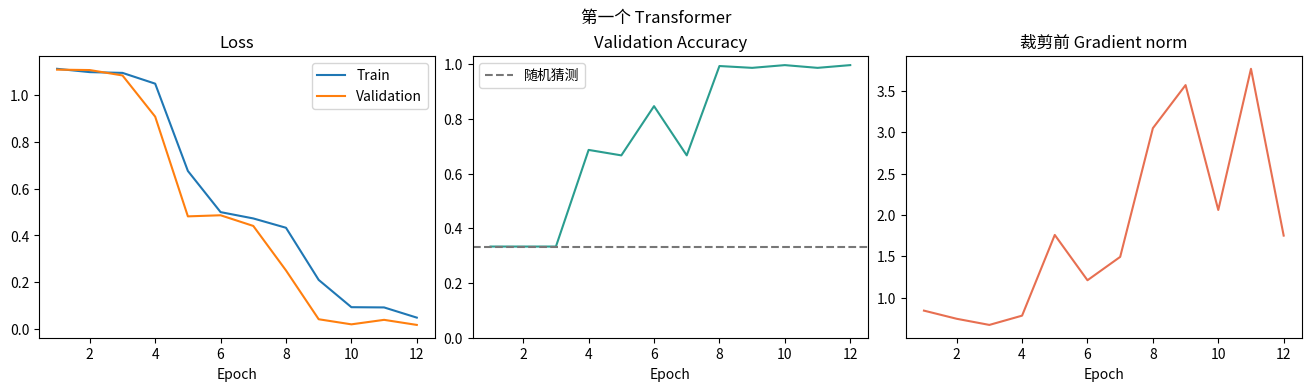

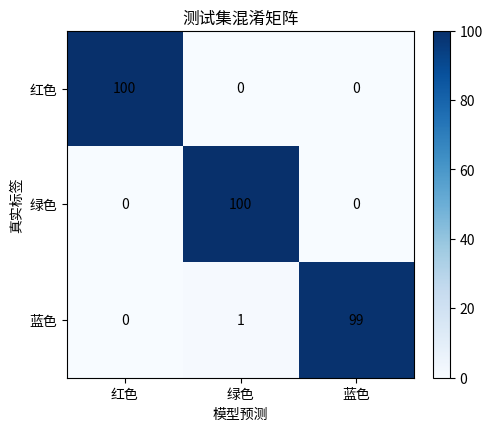

In [3]:
plot_training_history(result["history"], title=config.name)
plot_confusion_matrix(
    result["metrics"]["targets"],
    result["metrics"]["predictions"],
)


## 检查一条样本和 QUERY 的 Attention

这里仅重新计算一条样本最后一层的 Attention，不缓存全部 Batch 或全部 Epoch 的四维权重。

真实颜色： 蓝色
预测颜色： 蓝色
分类概率： [0.003000000026077032, 0.0010000000474974513, 0.9959999918937683]


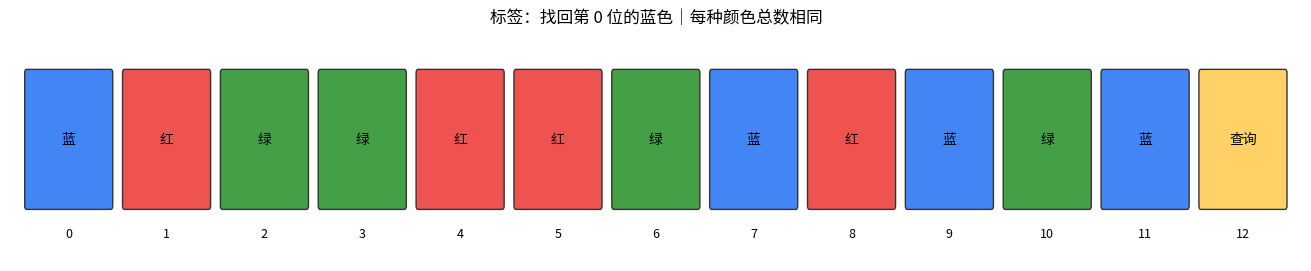

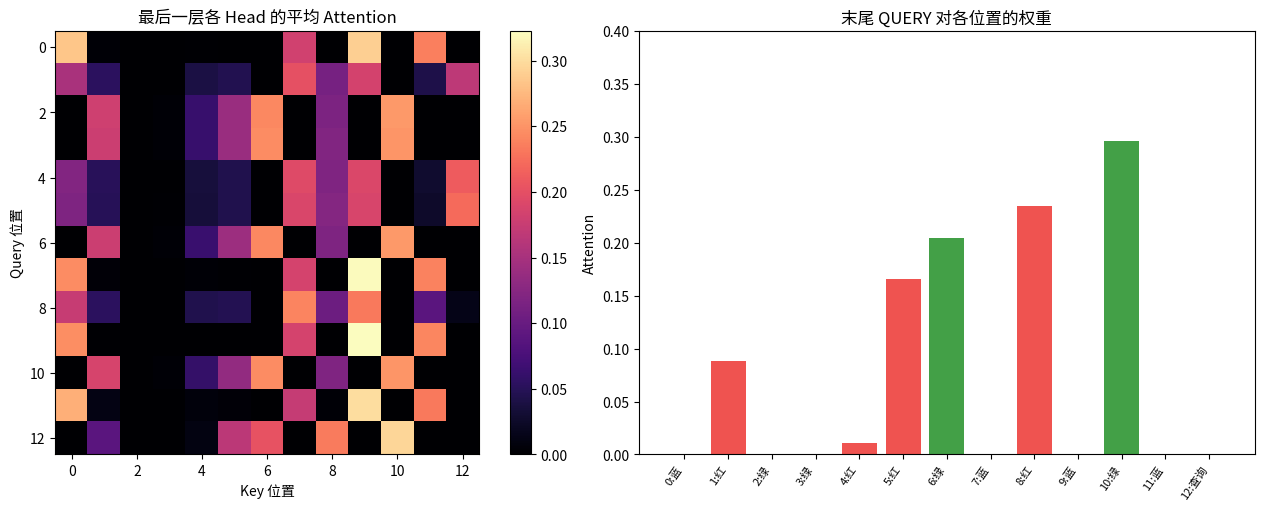

In [4]:
test_x, test_y = next(iter(result["loaders"]["test"]))
probabilities = predict_proba(result["model"], test_x[:1], device=DEVICE)[0]

plot_token_sequence(test_x, test_y, index=0)
plot_model_attention(result["model"], test_x[:1], device=DEVICE)

names = result["data"].class_names
print("真实颜色：", names[int(test_y[0])])
print("预测颜色：", names[int(probabilities.argmax())])
print("分类概率：", probabilities.numpy().round(3).tolist())


## 用自己的话补全

- Embedding 的作用是：__。
- 位置编码不可缺少的原因是：__。
- Residual 连接把 __ 与 __ 相加。
- LayerNorm 的作用不是“让 Accuracy 必然提高”，而是：__。
- 当前结果的适用边界是：当前合成任务、固定 seed、长度和训练预算。

## 完成本页后：释放资源并结束内核

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)
